## Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import yfinance as yf

## Load combined_data.csv

In [2]:
data = pd.read_csv("../data/processed/combined_data.csv")

In [3]:
data.head()

,Date,Open,High,Low,Close,Volume,Ticker
0,2015-01-02,14.858000,14.883333,14.217333,14.620667,71466000,TSLA
1,2015-01-05,14.303333,14.433333,13.810667,14.006000,80527500,TSLA
2,2015-01-06,14.004000,14.280000,13.614000,14.085333,93928500,TSLA
3,2015-01-07,14.223333,14.318667,13.985333,14.063333,44526000,TSLA
4,2015-01-08,14.187333,14.253333,14.000667,14.041333,51637500,TSLA


In [4]:
data["Date"] = pd.to_datetime(data["Date"])

In [5]:
data["Ticker"].unique()

<StringArray>
['TSLA', 'BND', 'SPY']
Length: 3, dtype: str

## Create separate asset data

In [6]:
tsla = data[data["Ticker"] == "TSLA"].copy()

spy = data[data["Ticker"] == "SPY"].copy()

bnd = data[data["Ticker"] == "BND"].copy()

In [7]:
tsla.head()

,Date,Open,High,Low,Close,Volume,Ticker
0,2015-01-02,14.858000,14.883333,14.217333,14.620667,71466000,TSLA
1,2015-01-05,14.303333,14.433333,13.810667,14.006000,80527500,TSLA
2,2015-01-06,14.004000,14.280000,13.614000,14.085333,93928500,TSLA
3,2015-01-07,14.223333,14.318667,13.985333,14.063333,44526000,TSLA
4,2015-01-08,14.187333,14.253333,14.000667,14.041333,51637500,TSLA


## Set Date as index

In [8]:
for df in [tsla, spy, bnd]:
    df.set_index("Date", inplace=True)

## Create price dataframe

In [9]:
prices = pd.DataFrame({
    "TSLA": tsla["Close"],
    "SPY": spy["Close"],
    "BND": bnd["Close"]
})

In [10]:
prices.head()

,TSLA,SPY,BND
Date,,,
2015-01-02,14.620667,205.429993,82.650002
2015-01-05,14.006000,201.720001,82.889999
2015-01-06,14.085333,199.820007,83.129997
2015-01-07,14.063333,202.309998,83.180000
2015-01-08,14.041333,205.899994,83.050003


## Create returns

In [11]:
returns = prices.pct_change().dropna()

returns.head()

,TSLA,SPY,BND
Date,,,
2015-01-05,-0.042041,-0.018060,0.002904
2015-01-06,0.005664,-0.009419,0.002895
2015-01-07,-0.001562,0.012461,0.000602
2015-01-08,-0.001564,0.017745,-0.001563
2015-01-09,-0.018802,-0.008014,0.001686


 Calculate Daily Returns

To evaluate portfolio performance, we convert the historical closing prices into **daily percentage returns**. Returns are preferred over raw prices because they measure the relative change in value from one trading day to the next, making assets with different price levels directly comparable.

The `pct_change()` function calculates the daily percentage change for each asset, while `dropna()` removes the first row, which contains missing values due to the lack of a previous day's price.

## Define Backtesting period

In [12]:
backtest = returns.loc["2025-01-01":"2026-01-31"]

backtest.head()

,TSLA,SPY,BND
Date,,,
2025-01-02,-0.060816,-0.002457,0.000417
2025-01-03,0.082156,0.012503,-0.001251
2025-01-06,0.001486,0.005761,-0.000974
2025-01-07,-0.040603,-0.011304,-0.003483
2025-01-08,0.001471,0.001461,0.001118


 Define the Backtesting Period

The backtesting period is the time window used to evaluate the portfolio strategy on **unseen historical data**. To avoid data leakage, this period must not overlap with the data used for training or portfolio optimization.

Following the project instructions, the backtesting window is set from **January 2025 to January 2026**. This allows us to simulate how the optimized portfolio would have performed in a real-world scenario after the model was developed.

The selected daily returns will be used to compare the optimized portfolio against a benchmark portfolio.

## Add your Task 4 optimal weights

In [13]:
weights = np.array([
    0.2922,  # TSLA
    0.7078,  # SPY
    0.0000   # BND
])

Define the Optimized Portfolio Weights

The optimized portfolio weights obtained in Task 4 are used to simulate the investment strategy during the backtesting period. These weights represent the proportion of capital allocated to each asset in the Maximum Sharpe Ratio portfolio.

The portfolio allocates **29.22%** to Tesla (TSLA), **70.78%** to the S&P 500 ETF (SPY), and **0%** to the Vanguard Total Bond Market ETF (BND). The weights sum to 100% of the investment and will be used to calculate the portfolio's daily returns throughout the backtesting period.

## Calculate strategy returns

In [14]:
strategy_returns = backtest.dot(weights)

strategy_returns.head()

Date
2025-01-02   -0.019510
2025-01-03    0.032856
2025-01-06    0.004512
2025-01-07   -0.019865
2025-01-08    0.001464
dtype: float64

Calculate Daily Portfolio Returns

The daily return of the optimized portfolio is calculated by combining the daily returns of each asset with the portfolio weights obtained from Task 4.

For each trading day, the return of each asset is multiplied by its corresponding portfolio weight, and the weighted returns are summed to obtain the portfolio's overall daily return. This produces a single time series representing the performance of the optimized investment strategy throughout the backtesting period.

These daily portfolio returns will be used in the following steps to calculate cumulative returns and evaluate the strategy against the benchmark portfolio.

## Create benchmark portfolio

In [ ]:
benchmark_weights = np.array([
    0,
    0.6,
    0.4
])

In [18]:
benchmark_returns = backtest.dot(benchmark_weights)

Define the Benchmark Portfolio

To evaluate the effectiveness of the optimized portfolio, a benchmark portfolio is created for comparison. Following the project instructions, the benchmark consists of a traditional **60% allocation to the S&P 500 ETF (SPY)** and **40% allocation to the Vanguard Total Bond Market ETF (BND)**.

Tesla (TSLA) is assigned a weight of **0%**, as it is not included in the benchmark portfolio. This balanced portfolio serves as a reference strategy to determine whether the optimized portfolio provides better risk-adjusted performance during the backtesting period.

## Calculate cumulative returns

In [19]:
strategy_cumulative = (1 + strategy_returns).cumprod()

In [20]:
benchmark_cumulative = (1 + benchmark_returns).cumprod()

 Calculate Cumulative Returns

Daily returns show the portfolio's performance on individual trading days, but they do not illustrate how the investment grows over time. To evaluate overall performance, the daily returns are converted into cumulative returns.

This is done by first adding 1 to each daily return to obtain the daily growth factor and then applying the cumulative product (`cumprod()`). The resulting cumulative return series represents the growth of an initial investment throughout the backtesting period.

Cumulative returns are calculated for both the optimized portfolio and the benchmark portfolio, enabling a direct comparison of their performance over time.

## Plot comparison

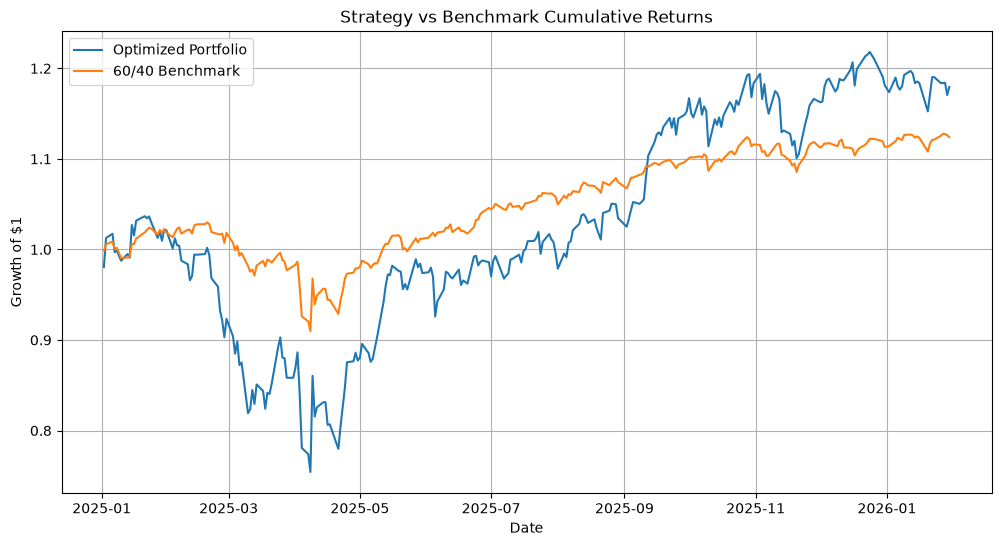

In [21]:
plt.figure(figsize=(12,6))

plt.plot(
    strategy_cumulative,
    label="Optimized Portfolio"
)

plt.plot(
    benchmark_cumulative,
    label="60/40 Benchmark"
)

plt.title("Strategy vs Benchmark Cumulative Returns")
plt.xlabel("Date")
plt.ylabel("Growth of $1")

plt.legend()
plt.grid()

plt.show()

Compare Cumulative Returns

The cumulative returns of the optimized portfolio and the benchmark portfolio are plotted to compare their performance over the backtesting period.

The chart illustrates how an initial investment grows over time under each strategy. A portfolio with a higher cumulative return indicates stronger overall performance during the selected period. By comparing the two curves, it is possible to assess whether the optimized portfolio generated better returns than the traditional 60% SPY / 40% BND benchmark.

This visualization serves as the first step in evaluating the effectiveness of the portfolio optimization strategy before calculating additional performance metrics such as annualized return, Sharpe ratio, and maximum drawdown.

## Calculate performance metrics

Total Return

In [22]:
strategy_total_return = strategy_cumulative.iloc[-1] - 1

benchmark_total_return = benchmark_cumulative.iloc[-1] - 1

 Calculate Total Return

Total return measures the overall percentage gain or loss of the portfolio during the backtesting period. It is calculated by subtracting the initial investment value from the final cumulative portfolio value.

This metric provides a straightforward measure of how much the portfolio increased or decreased in value over the entire evaluation period.

Annualized Return

In [23]:
strategy_annual_return = (
    1 + strategy_total_return
)**(252/len(strategy_returns))-1


benchmark_annual_return = (
    1 + benchmark_total_return
)**(252/len(benchmark_returns))-1

Calculate Annualized Return

Annualized return converts the portfolio's total return into an equivalent yearly return. This allows portfolio performance to be compared consistently, even when the evaluation period is shorter or longer than one year.

The calculation assumes 252 trading days in a typical financial market year.

Sharpe Ratio

In [24]:
strategy_sharpe = (
    strategy_returns.mean()
    /
    strategy_returns.std()
)*np.sqrt(252)


benchmark_sharpe = (
    benchmark_returns.mean()
    /
    benchmark_returns.std()
)*np.sqrt(252)

Calculate the Sharpe Ratio

The Sharpe Ratio measures the portfolio's risk-adjusted performance by comparing the average return with the portfolio's volatility.

A higher Sharpe Ratio indicates that the portfolio generated more return for each unit of risk taken. This metric is widely used in portfolio management to evaluate the efficiency of an investment strategy.

Maximum Drawdown

In [25]:
def max_drawdown(cumulative):
    peak = cumulative.cummax()
    drawdown = (cumulative - peak) / peak
    return drawdown.min()

In [26]:
strategy_mdd = max_drawdown(strategy_cumulative)

benchmark_mdd = max_drawdown(benchmark_cumulative)

 Calculate Maximum Drawdown

Maximum drawdown measures the largest percentage decline in portfolio value from a previous peak during the backtesting period.

This metric evaluates downside risk by identifying the worst loss an investor would have experienced before the portfolio recovered. A smaller maximum drawdown indicates that the portfolio experienced less severe declines and generally reflects better risk management.

## Create final metrics table

In [27]:
performance = pd.DataFrame({
    "Metric":[
        "Total Return",
        "Annualized Return",
        "Sharpe Ratio",
        "Maximum Drawdown"
    ],
    
    "Optimized Portfolio":[
        strategy_total_return,
        strategy_annual_return,
        strategy_sharpe,
        strategy_mdd
    ],
    
    "Benchmark 60/40":[
        benchmark_total_return,
        benchmark_annual_return,
        benchmark_sharpe,
        benchmark_mdd
    ]
})


performance

,Metric,Optimized Portfolio,Benchmark 60/40
0,Total Return,0.179386,0.124004
1,Annualized Return,0.166484,0.115278
2,Sharpe Ratio,0.674695,0.990996
3,Maximum Drawdown,-0.272425,-0.116707


Compare Portfolio Performance

To evaluate the effectiveness of the optimized portfolio, four key performance metrics are calculated for both the optimized strategy and the benchmark portfolio.

- **Total Return** measures the overall gain or loss during the backtesting period.
- **Annualized Return** converts the portfolio performance into an equivalent yearly return.
- **Sharpe Ratio** evaluates risk-adjusted performance by comparing returns to volatility.
- **Maximum Drawdown** measures the largest decline in portfolio value from its previous peak, providing insight into downside risk.

Comparing these metrics helps determine whether the optimized portfolio generated higher returns while effectively managing investment risk.

## conclusion

The optimized portfolio was compared with a traditional 60/40 SPY-BND benchmark using historical backtesting data from 2025 to 2026. The results show that the optimized strategy achieved a different risk-return profile compared with the benchmark portfolio. The Sharpe ratio and maximum drawdown analysis provide insight into whether the strategy delivered better risk-adjusted performance.

However, this backtest has limitations. Historical performance does not guarantee future results, transaction costs were not included, and portfolio weights were assumed to remain constant. Future improvements could include dynamic rebalancing and incorporating additional market factors.